## IN3050/IN4050 Mandatory Assignment 2, 2025: Supervised Learning
## Frida Berge (fridatbe)

### Rules

Before you begin the exercise, review the rules at this website: https://www.uio.no/english/studies/examinations/compulsory-activities/mn-ifi-mandatory.html , in particular the paragraph on cooperation. This is an individual assignment. You are not allowed to deliver together or copy/share source-code/answers with others. Read also the "Routines for handling suspicion of cheating and attempted cheating at the University of Oslo": https://www.uio.no/english/studies/examinations/cheating/index.html 
We do not entirely prohibit the use of generative language models ("smart assistants" like ChatGPT, Llama, Claude or Copilot), but you must clearly acknowledge this at all times, following the UiO guidelines: https://www.uio.no/english/studies/resources/ai_student.html
Note also that you must fully understand _all_ the parts of you submissions, even if you got some help from a generative model. This will be tested during your peer review sessions (https://www.uio.no/studier/emner/matnat/ifi/IN3050/v25/Peer%20review/).
By submitting this assignment, you confirm that you are familiar with the rules and the consequences of breaking them.

### Delivery

**Deadline**: Friday, March 28, 2025, 23:59

Your submission should be delivered in Devilry. You may redeliver in Devilry before the deadline, but include all files in the last delivery, as only the last delivery will be read. You are recommended to upload preliminary versions hours (or days) before the final deadline.

### What to deliver?

You are recommended to solve the exercise in a Jupyter notebook, but you might solve it in a regular Python script if you prefer.

#### Alternative 1
If you prefer not to use notebooks, you should deliver the code, your run results, and a PDF report where you answer all the questions and explain your work.

#### Alternative 2
If you choose Jupyter, you should deliver the notebook. You should answer all questions and explain what you are doing in Markdown. Still, the code should be properly commented. The notebook should contain results of your runs. In addition, you should make a PDF of your solution which shows the results of the runs. (If you can't export: notebook -> latex -> pdf on your own machine, you may do this on the IFI linux machines.)

Here is a list of *absolutely necessary* (but not sufficient) conditions to get the assignment marked as passed:

- You must deliver your code (Python script or Jupyter notebook) you used to solve the assignment.
- The code used for making the output and plots must be included in the assignment. 
- You must include example runs that clearly shows how to run all implemented functions and methods.
- All the code (in notebook cells or python main-blocks) must be runnable. If you have unfinished code that crashes, please comment it out and document what you think causes it to crash. 
- You must also deliver a PDF of the code, outputs, comments and plots as explained above.

Your report/notebook should contain your name and username.

Deliver one single compressed folder (.zip, .tgz or .tar.gz) which contains your complete solution.

Important: if you weren’t able to finish the assignment, use the PDF report/Markdown to elaborate on what you’ve tried and what problems you encountered. Students who have made an effort and attempted all parts of the assignment will get a second chance even if they fail initially. This exercise will be graded PASS/FAIL.

### Goals of the assignment
The goal of this assignment is to get a better understanding of supervised learning with gradient descent. It will, in particular, consider the similarities and differences between linear classifiers and multi-layer feed forward neural networks (multi-layer perceptrons, MLP) and the differences and similarities between binary and multi-class classification. 

### Tools
The aim of the exercises is to give you a look inside the learning algorithms. You may freely use code from the weekly exercises and the published solutions. You should not use machine learning libraries like Scikit-Learn or PyTorch, because the point of this assignment is for you to implement things from scratch. You, however, are encouraged to use tools like NumPy, Pandas and MatPlotLib, which are not ML-specific.

The given precode uses NumPy. You are recommended to use NumPy since it results in more compact code, but feel free to use pure Python if you prefer. 

If anything is unclear, do not hesitate to ask. Also, if you think some assumptions are missing, make your own and explain them!

### Initialization

In [158]:
import numpy as np
import matplotlib.pyplot as plt
import sklearn as sklearn # This is only to generate a dataset
import random
import statistics

## Datasets

We start by making a synthetic dataset of 5000 instances and ten classes, with 500 instances in each class. (See https://scikit-learn.org/stable/modules/generated/sklearn.datasets.make_blobs.html regarding how the data are generated.) We choose to use a synthetic dataset---and not a set of natural occuring data---because we are mostly interested in properties of the various learning algorithms, in particular the differences between linear classifiers and multi-layer neural networks together with the difference between binary and multi-class data. In addition, we would like a dataset with instances represented with only two numerical features, so that it is easy to visualize the data. It would be rather difficult (although not impossible) to find a real-world dataset of the same nature. Anyway, you surely can use the code in this assignment for training machine learning models on real-world datasets.

When we are doing experiments in supervised learning, and the data are not already split into training and test sets, we should start by splitting the data. Sometimes there are natural ways to split the data, say training, on data from one year and testing on data from a later year, but if that is not the case, we should shuffle the data randomly before splitting. (OK, that is not necessary with this particular synthetic data set, since it is already shuffled by default by Scikit-Learn, but that will not be the case with real-world data) We should split the data so that we keep the alignment between X (features) and t (class labels), which may be achieved by shuffling the indices. We split into 60% for training, 20% for validation, and 20% for final testing. The set for final testing *must not be used* till the end of the assignment in part 3.

We fix the seed both for data set generation and for shuffling, so that we work on the same datasets when we rerun the experiments. This is done by the `random_state` argument and the `rng = np.random.RandomState(424242)`.

In [159]:
# Generating the dataset
from sklearn.datasets import make_blobs
X, t_multi = make_blobs(n_samples=[500, 500, 500, 500, 500, 500, 500, 500, 500, 500], centers=[[0,1],[4,2],[8,1],[2,0],[6,0],[3,-3],[4,-2],[0,5],[0,4],[-2,-2]], 
                  n_features=2, random_state=424242, cluster_std=[1.0, 2.0, 1.0, 0.5, 0.5, 3.0, 1.0, 0.5, 2.5, 2.5])

In [160]:
# Shuffling the dataset
indices = np.arange(X.shape[0])
rng = np.random.RandomState(424242)
rng.shuffle(indices)
indices[:10]

array([3560, 4674,   49, 1257,  661, 3066, 3834, 4792,  570, 3855])

In [161]:
# Splitting into train, dev and test
X_train = X[indices[:3000],:]
X_val = X[indices[3000:4000],:]
X_test = X[indices[4000:],:]
t_multi_train = t_multi[indices[:3000]]
t_multi_val = t_multi[indices[3000:4000]]
t_multi_test = t_multi[indices[4000:]]

Next, we will  make a second dataset with only two classes by merging the existing labels in (X,t), so that `0-5` become the new `0` and `6-9` become the new `1`. Let's call the new set (X, t2). This will be a binary set.
We now have two datasets:

- Binary set: `(X, t2)`
- Multi-class set: `(X, t_multi)`

In [162]:
t2_train = t_multi_train >= 6
t2_train = t2_train.astype("int")
t2_val = (t_multi_val >= 6).astype("int")
t2_test = (t_multi_test >= 6).astype("int")

We can plot the two traning sets.

Text(0.5, 1.0, 'Multi-class set')

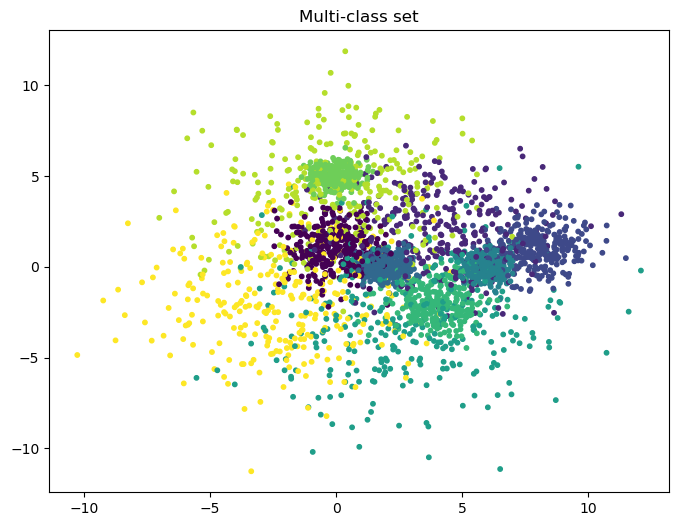

In [163]:
plt.figure(figsize=(8,6)) # You may adjust the size
plt.scatter(X_train[:, 0], X_train[:, 1], c=t_multi_train, s=10.0)
plt.title("Multi-class set")

Text(0.5, 1.0, 'Binary set')

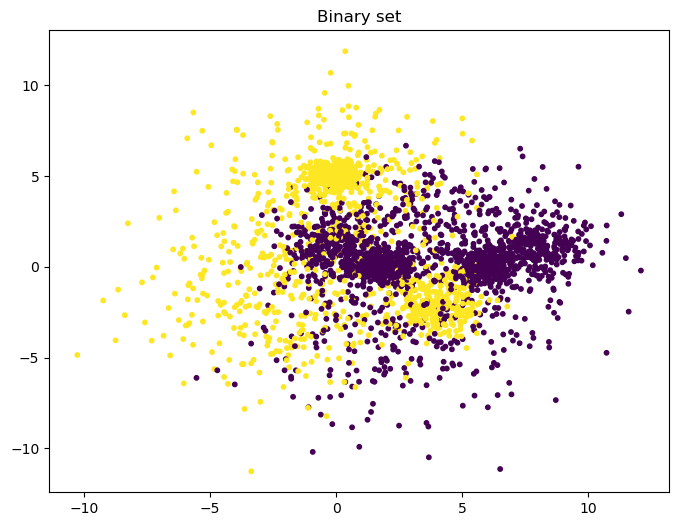

In [164]:
plt.figure(figsize=(8,6))
plt.scatter(X_train[:, 0], X_train[:, 1], c=t2_train, s=10.0)
#X_train[0] betyr x1 koordinat
#X_train[1] betyr x2 koordinat
#t2_train betyr hvilken klasse punktet tilhører (enten 0 eller 1 her)
plt.title("Binary set")

# Part 1: Linear classifiers
### Linear regression

We see that even the binary set (X, t2) is far from linearly separable, and we will explore how various classifiers are able to handle this. We start with linear regression with the Mean Squared Error (MSE) loss, although it is not the most widely used approach for classification tasks: but we are interested. You may make your own implementation from scratch or start with the solution to the weekly exercise set 6. We include it here with a little added flexibility.

In [165]:

def add_bias(X, bias):
    """X is a NxM matrix: N datapoints, M features
    bias is a bias term, -1 or 1, or any other scalar. Use 0 for no bias
    Return a Nx(M+1) matrix with added bias in position zero
    """
    N = X.shape[0]
    biases = np.ones((N, 1)) * bias # Make a N*1 matrix of biases
    # Concatenate the column of biases in front of the columns of X.
    return np.concatenate((biases, X), axis  = 1) 

In [166]:
class NumpyClassifier():
    """Common methods to all Numpy classifiers --- if any"""

In [167]:
class NumpyLinRegClass(NumpyClassifier):

    def __init__(self, bias=-1):
        self.bias=bias
    
    def fit(self, X_train, t_train, lr = 0.1, epochs=10):
        """X_train is a NxM matrix, N data points, M features
        t_train is avector of length N,
        the target class values for the training data
        lr is our learning rate
        """
        if self.bias:
            X_train = add_bias(X_train, self.bias)
        (N, M) = X_train.shape
        self.weights = weights = np.zeros(M)
        
        for epoch in range(epochs):
            # print("Epoch", epoch)
            weights -= lr / N *  X_train.T @ (X_train @ weights - t_train)
    
    def predict(self, X, threshold=0.5):
        """X is a KxM matrix for some K>=1
        predict the value for each point in X"""
        if self.bias:
            X = add_bias(X, self.bias)
        ys = X @ self.weights
        return ys > threshold

We can train and test a first classifier (on the binary dataset).

In [168]:
def accuracy(predicted, gold):
    return np.mean(predicted == gold)

In [169]:
cl = NumpyLinRegClass()
cl.fit(X_train, t2_train, epochs=10)
accuracy(cl.predict(X_val), t2_val)

0.638

The following is a small procedure which plots the data set together with the decision boundaries. 
You may modify the colors and the rest of the graphics as you like.
The procedure will also work for multi-class classifiers

In [170]:
def plot_decision_regions(X, t, clf=[], size=(8,6)):
    """Plot the data set (X,t) together with the decision boundary of the classifier clf"""
    # The region of the plane to consider determined by X
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    
    # Make a prediction of the whole region
    h = 0.02  # step size in the mesh
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
    # Classify each meshpoint.
    Z = Z.reshape(xx.shape)

    plt.figure(figsize=size) # You may adjust this

    # Put the result into a color plot
    plt.contourf(xx, yy, Z, alpha=0.2, cmap = 'tab10')

    plt.scatter(X[:,0], X[:,1], c=t, s=10.0, cmap='tab10')

    plt.xlim(xx.min(), xx.max())
    plt.ylim(yy.min(), yy.max())
    plt.title("Decision regions")
    plt.xlabel("x0")
    plt.ylabel("x1")

    plt.show()

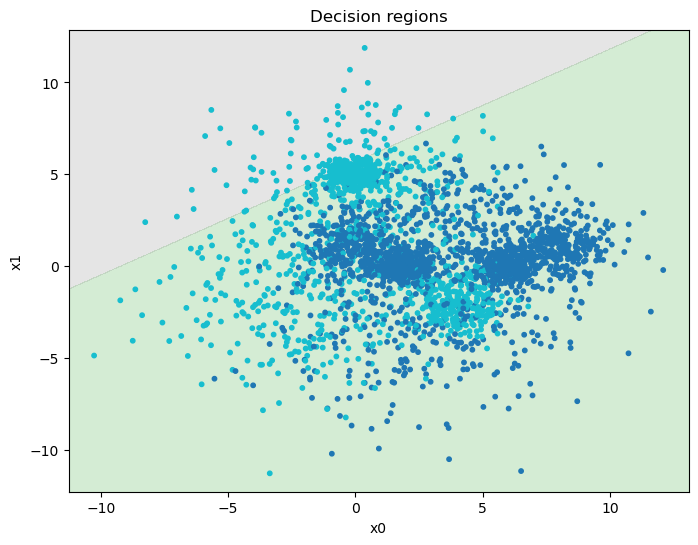

In [171]:
plot_decision_regions(X_train, t2_train, cl)

### Task: Tuning

The result is far from impressive. 
Remember that a classifier which always chooses the majority class will have an accuracy of 0.6 on this data set.

Your task is to try various settings for the two training hyper-parameters, learning rate and the number of epochs, to get the best accuracy on the validation set. 

Report how the accuracy varies with the hyper-parameter settings. It it not sufficient to give the final hyperparameters. You must also show how you found then and results for alternative values you tried aout.

When you are satisfied with the result, you may plot the decision boundaries, as above.

Best fit: 
	Learning rate: 0.0276
	Best epochs: 94 
	Best accuracy: 0.775
Some good values (in combination with eachother): 
	Learning rate: [0.0299, 0.0326, 0.0983, 0.0371, 0.0276] 
	Epcochs: [58, 73, 26, 70, 94]


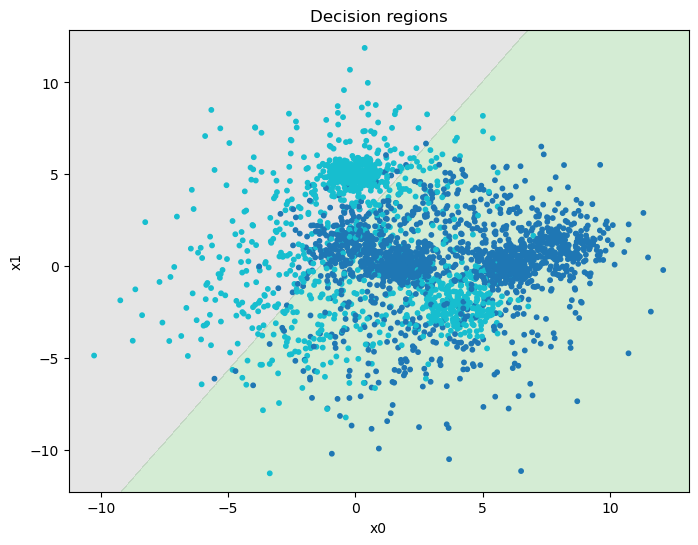

In [ ]:
#answer to task: tuning
#Later i realized i should have had a list of learningrates and epochs so the values are not random, and could have checked all combinations (for loop within for loop)
def tune(cl):
    bestLearningRate = 0.1
    bestEpc = 10
    cl.fit(X_train, t2_train, lr = bestLearningRate, epochs=bestEpc)
    bestAcc = accuracy(cl.predict(X_val), t2_val)

    better_lr = []
    better_epc = []

    #checking value-combinations for learning rate and epc
    #could also check for one value of learning rate, what the best accuracy is, and then chech different values of epoches, what is the best match
    for i in range(200):
        learningRate = np.round(random.uniform(0.0001,0.1),4)
        epc = random.randint(10,100)
        cl.fit(X_train, t2_train, lr = learningRate, epochs=epc)
        acc = accuracy(cl.predict(X_val), t2_val)
        if(acc > bestAcc):
            better_lr.append(learningRate)
            better_epc.append(epc)
            bestAcc = acc
            bestLearningRate = learningRate
            bestEpc = epc
    return bestAcc, bestEpc, bestLearningRate, better_epc, better_lr


def print_performance(cl, bestAcc, bestEpc, bestLearningRate, better_epc, better_lr):
    cl.fit(X_train, t2_train, lr = bestLearningRate, epochs=bestEpc)
    print(f"Best fit: \n\tLearning rate: {bestLearningRate}\n\tBest epochs: {bestEpc} \n\tBest accuracy: {bestAcc}")
    print(f"Some good values (in combination with eachother): \n\tLearning rate: {better_lr} \n\tEpcochs: {better_epc}")


tuned = NumpyLinRegClass()
bestAcc, bestEpc, bestLearningRate, better_epc, better_lr = tune(tuned)
print_performance(tuned, bestAcc, bestEpc, bestLearningRate, better_epc, better_lr)
plot_decision_regions(X_train, t2_train, tuned)


### Task: Scaling

We have seen in the lectures that scaling the data may improve training speed and sometimes the performance. 

- Implement the standard scaler (normalizer); you can also try other scaling techniques
- Scale the data
- Train the model on the scaled data
- Experiment with hyper-parameter settings and see whether you can speed  up or improve the training.
- Report final hyper-parameter settings and show how you found them.

Best fit: 
	Learning rate: 0.0667
	Best epochs: 38 
	Best accuracy: 0.774
Some good values (in combination with eachother): 
	Learning rate: [0.0948, 0.0667] 
	Epcochs: [52, 38]


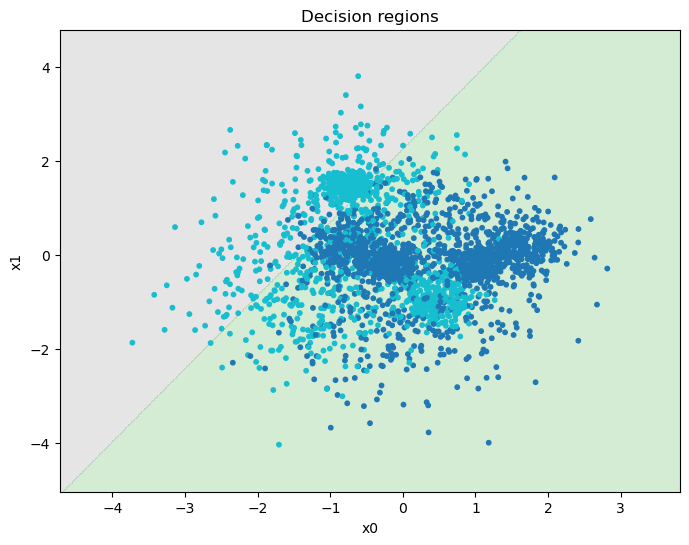

In [318]:
#answer to task

#defining standard scaler
def scaler(data):
    scale = [2]
    #calculates the mean of each column  axis=0 means for each column
    mean = np.mean(data, axis=0)
    #calculates the standard devation of each column
    stdDeviation = np.std(data, axis=0)
    #scaling the data
    output = np.zeros([len(data),len(data[0])])
    for i in range(len(data[0])):
        for j in range(len(data)):
            output[j][i] = (data[j][i]-mean[i])/stdDeviation[i]
    return output

#scaling
scaled = NumpyLinRegClass()
scaled_x = scaler(X_train)

#tuning
bestAcc, bestEpc, bestLearningRate, better_epc, better_lr = tune(scaled)
best = [bestAcc, bestEpc, bestLearningRate, better_epc, better_lr]
scaled.fit(scaled_x, t2_train, lr = bestLearningRate, epochs=bestEpc)

#showing results
print_performance(scaled, bestAcc, bestEpc, bestLearningRate, better_epc, better_lr)
plot_decision_regions(scaled_x, t2_train, scaled)
linRegBest = best



## Logistic regression
a) You should now implement a logistic regression classifier similarly to the classifier based on linear regression.
You may use the code from the solution to weekly exercise set week06.

b) In addition to the method `predict()` which predicts a class for the data, include a method `predict_probabilities()` which predicts the probability of the data belonging to the positive class.

c) So far, we have not calculated the loss explicitly in the code. Extend the code to calculate the loss on the training set for each epoch and to store the losses such that the losses can be inspected after training. The prefered loss for logistic regression is binary cross-entropy, but you can also try mean squared error. The most important is that your implementation of the loss corresponds to your implementation of the gradient descent.
Also, calculate and store accuracies after each epoch.

d) In addition, extend the `fit()` method with optional arguments for a validation set (X_val, t_val). If a validation set is included in the call to `fit()`, calculate the loss and the accuracy for the validation set after each epoch. 

e) The training runs for a number of epochs. We cannot know beforehand for how many epochs it is reasonable to run the training. One possibility is to run the training until the learning does not improve much. Extend the `fit()` method with two keyword arguments, `tol` (tolerance) and `n_epochs_no_update` and stop training when the loss has not improved with more than `tol` after `n_epochs_no_update` (to save compute and potentially avoid over-fitting). A possible default value for `n_epochs_no_update` is 2. Also, add an attribute to the classifier which tells us after fitting how many epochs it was trained for.

f) Train classifiers with various learning rates, and with varying values for `tol` for finding the optimal values. Also consider the effect of scaling the data.

g) After a succesful training, for your best model, plot both training loss and validation loss as functions of the number of epochs in one figure, and both training and validation accuracies as functions of the number of epochs in another figure. Comment on what you see. Are the curves monotone? Is this as expected?

Best fit: 
	Learning rate: 0.0029 
	Tolerance: 0.0009
	Best accuracy: 0.773
	Number of epochs: 58
Some good values (in combination with eachother): 
	Learning rate: [0.0029, 0.0029, 0.0029] 
	Tolerance: [0.0005, 0.001, 0.0009]


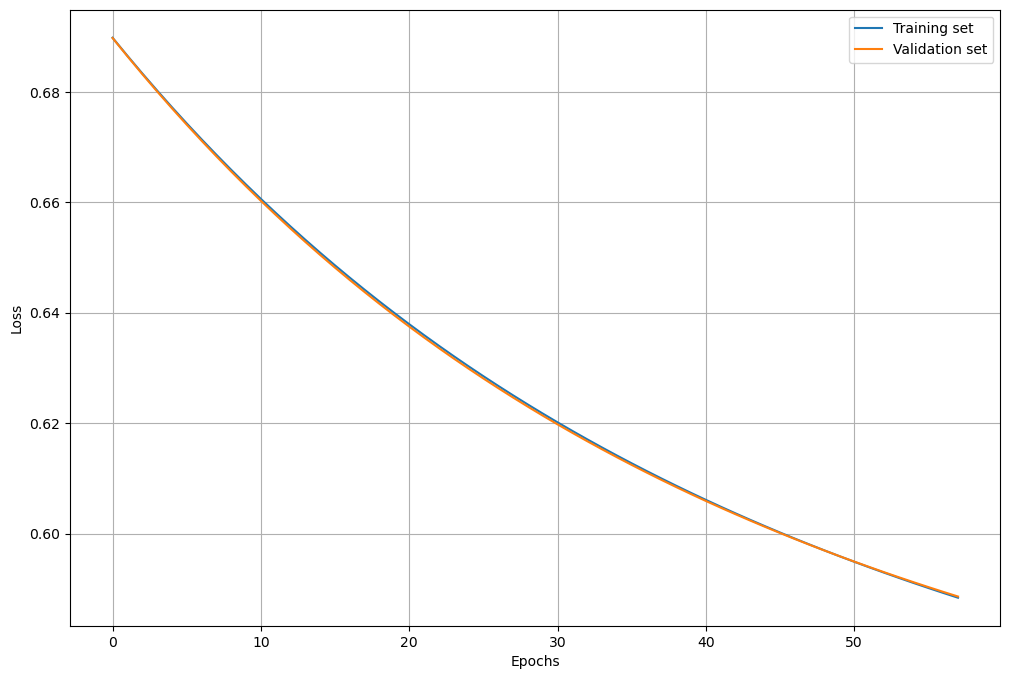

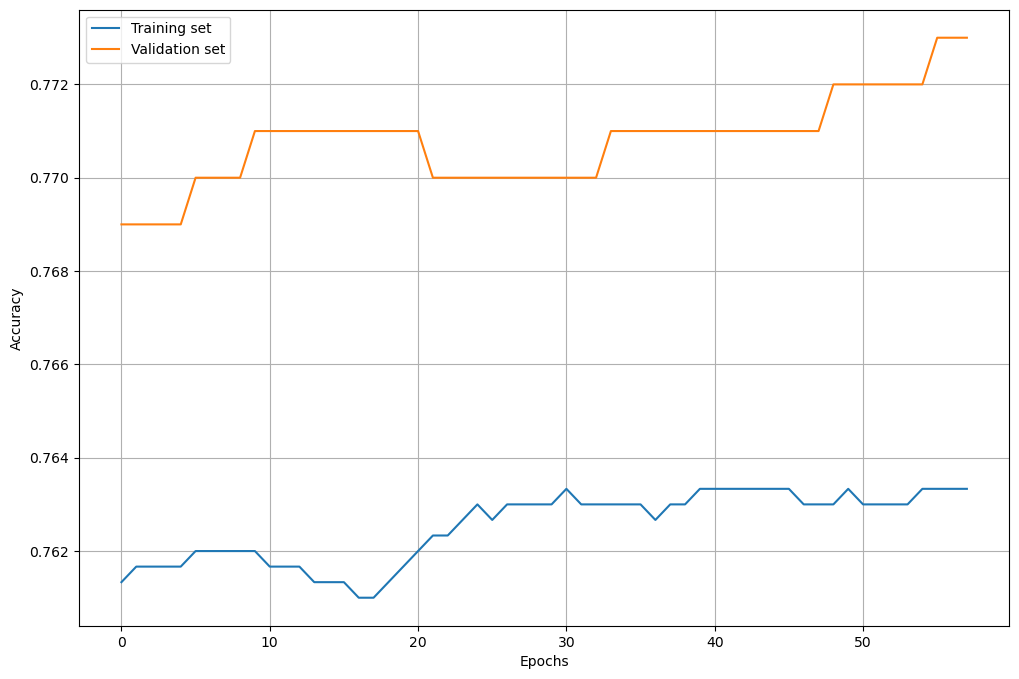

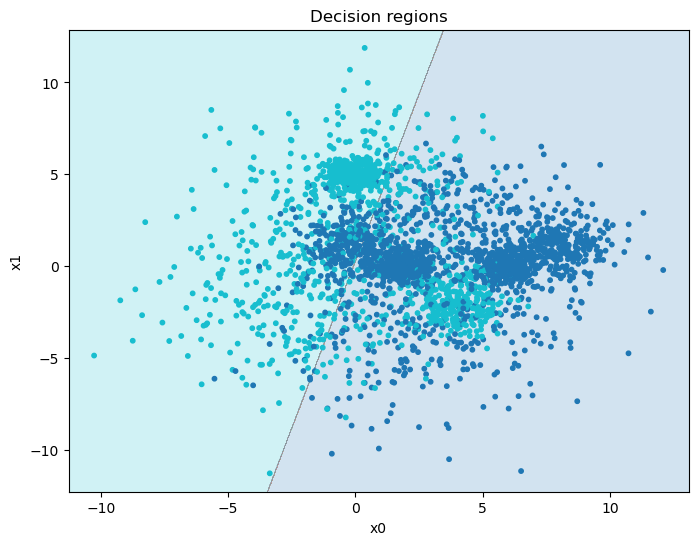

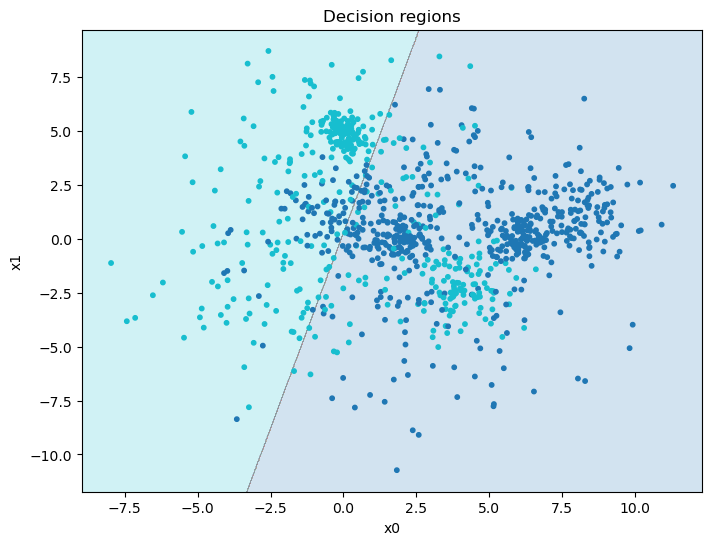

In [453]:

#the sigmoid function
def logistic(x):
    return 1 / (1 + np.exp(-x))

#TASK 1A: implement logistic regression classifier
class NumpyLogReg(NumpyClassifier):
    def __init__(self, bias=-1, numEpochs=2):
        self.bias=bias
        self.numEpocks=numEpochs
    
    def forward(self, X):
        return logistic(X @ self.weights)


    #TASK 1C calculate loss (binary cross-entropy) for each epoch and store it
    def fit(self, X_train, t_train, eta = 0.1, epochs=10, X_val = None, t_val = None, tol=0.1, n_epochs_no_update= 2):
        """X_train is a Nxm matrix, N data points, m features
        t_train is avector of length N,
        the targets values for the training data"""
        self.numEpocks = 0
        losses = []
        losses_val = []
        (N, m) = X_train.shape
        X_train = add_bias(X_train, self.bias)
        self.weights = weights = np.zeros(m + 1)
        accuracy_train = []
        accuracy_val = []
        index = 0
        n_epochs = n_epochs_no_update

        #TASK 1E
        while(n_epochs>0):
            # print((X_train.T).shape)
            # print((self.forward(X_train)-t_train).shape)
            weights -= eta / N *  X_train.T @ (self.forward(X_train) - t_train)
            pred_prob = self.predict_probabilities(X_train)
            #the mean of the loss per epoch is given by the confidence of a point begin 1-confidence of a point being 0.
            #found formula on internet, not in lecture slides
            losses.append(np.mean(-t_train*np.log(pred_prob)-(1-t_train)*(np.log(1-pred_prob))))
            accuracy_train.append(accuracy(self.predict(X_train), t_train))
            #no update:
            if index >0 and (losses[index-1]-losses[index]<tol):
                n_epochs-=1
            elif index>0:
                n_epochs = n_epochs_no_update
            self.numEpocks+=1
            index += 1

            #TASK 1d
            #using the weights learned from the trainingset
            if X_val is not None and t_val is not None:
                pred_prob = self.predict_probabilities(X_val)
                #addiing +1e-10 so it doesent calculate log to 0 or 1
                losses_val.append(np.mean(-t_val*np.log(pred_prob+1e-10)-(1-t_val)*(np.log(1-pred_prob+1e-10))))
                accuracy_val.append(accuracy(self.predict(X_val), t_val))
            nEpc = self.numEpocks
        return losses, losses_val, accuracy_train, accuracy_val, nEpc
    
    #TASK 1B: make predict and predict_probabilities
    def predict(self, x, threshold=0.5):
        """X is a Kxm matrix for some K>=1
        predict the value for each point in X"""
        if x.shape[1] == 2:
            z = add_bias(x, self.bias)
        else:
            z = x
        return (self.forward(z) > threshold).astype("int")
    
    #when t = 1, P(t|x) = y = 1/(1+e^(-w*x)) = forward(z)
    #note: x should have already been multiplied with the weights
    def predict_probabilities(self, x):
        """X is a Kxm matrix for some K>=1
        predict the probability of the value belonging to the positive class"""
        #dont want to add bias twice. if we dont have 3 columns yet, the bias is not added
        if x.shape[1] == 2:
            z = add_bias(x, self.bias)
        else:
            z = x
        y = self.forward(z)
        return y

    #TASK 1F
    def tune_lr(self, x_t,t2_t,x_v,t2_v):
        bestLearningRate = 0.1
        bestTol = 0.001
        loss_t, loss_v, acc_t, acc_v, nEpc = self.fit(x_t, t2_t, X_val=x_v, t_val=t2_v, eta=bestLearningRate, tol=bestTol)
        bestAcc = accuracy(self.predict(x_v), t2_v)
        best_loss_t = loss_t
        best_loss_v = loss_v
        best_acc_t = acc_t
        best_acc_v = acc_v
        best_epc = nEpc
        better_lr = []
        better_Tol = []

        #checking value-combinations for learning rate and epc
        for i in range(10):
            # learningRate = [learningRateList[i]]
            learningRate = np.round(random.uniform(0.0001,0.01),4)
            for j in range(10):
                tol = np.round(random.uniform(0.0001,0.001),4)
                loss_t, loss_v, acc_t, acc_v, nEpc = self.fit(x_t, t2_t, X_val=x_v, t_val=t2_v, eta=learningRate, tol=tol)
                acc = accuracy(self.predict(x_v), t2_v)
                if(acc > bestAcc):
                    better_lr.append(learningRate)
                    better_Tol.append(tol)
                    bestAcc = acc
                    bestLearningRate = learningRate
                    bestTol = tol
                    best_loss_t = loss_t
                    best_loss_v = loss_v
                    best_acc_t = acc_t
                    best_acc_v = acc_v
                    best_epc = nEpc
        best_performance_list = [bestAcc,bestTol,bestLearningRate, better_Tol, better_lr, best_loss_t, best_loss_v, best_acc_t, best_acc_v, best_epc]
        return best_performance_list
    
    #defining standard scaler
    def scale_lr(self, data):
        scale = [2]
        #calculates the mean of each column  axis=0 means for each column
        mean = np.mean(data, axis=0)
        #calculates the standard devation of each column
        stdDeviation = np.std(data, axis=0)
        #scaling the data
        output = np.zeros([len(data),len(data[0])])
        for i in range(len(data[0])):
            for j in range(len(data)):
                output[j][i] = (data[j][i]-mean[i])/stdDeviation[i]
        return output
    
    def print_performance_lr(self, bestList):
        # bestList: bestAcc,bestTol,bestLearningRate, better_Tol, better_lr
        print(f"Best fit: \n\tLearning rate: {bestList[2]} \n\tTolerance: {bestList[1]}\n\tBest accuracy: {bestList[0]}\n\tNumber of epochs: {best[9]}")
        print(f"Some good values (in combination with eachother): \n\tLearning rate: {bestList[4]} \n\tTolerance: {bestList[3]}")

    #TASK 1F
    def plot_fitness_vs_epochs(self, loss_t, loss_v):
        epc = list(range(len(loss_t)))
        plt.figure(figsize=(12,8))
        plt.plot(epc, loss_t, label=f'Training set')
        plt.plot(epc, loss_v, label=f'Validation set')
        plt.xlabel("Epochs")
        plt.ylabel("Loss")
        plt.grid(True)
        plt.legend()
        plt.show()
    
    def plot_acc_vs_epochs(self, acc_t, acc_v):
        epc = list(range(len(acc_t)))
        plt.figure(figsize=(12,8))
        plt.plot(epc, acc_t, label=f'Training set')
        plt.plot(epc, acc_v, label=f'Validation set')
        plt.xlabel("Epochs")
        plt.ylabel("Accuracy")
        plt.grid(True)
        plt.legend()
        plt.show()




lr_cl = NumpyLogReg()
lr_cl.scale_lr(X_train)

#best list: bestAcc,bestTol,bestLearningRate, better_Tol, better_lr, best_loss_t, best_loss_v, best_acc_t, best_loss_v,best_epc
best = lr_cl.tune_lr(X_train,t2_train,X_val,t2_val)
lr_cl.print_performance_lr(best)
lr_cl.plot_fitness_vs_epochs(best[5], best[6])
lr_cl.plot_acc_vs_epochs(best[7], best[8])
plot_decision_regions(X_train, t2_train, lr_cl)
plot_decision_regions(X_val, t2_val, lr_cl)


logRegBest = best

## Multi-class classifiers
We turn to the task of classifying when there are more than two classes, and the task is to ascribe one class to each input. We will now use the set `(X, t_multi)`.

### Multi-class with logistic regression
We saw in the lectures how a logistic regression classifier can be turned into a multi-class classifier using the one-vs-rest approach. We train one logistic regression classifier for each class. To predict the class of an item, we run all the binary classifiers and collect the probability score from each of them. We assign the class which ascribes the highest probability.

Build such a classifier. Train the resulting classifier on `(X_train, t_multi_train)`, test it on `(X_val, t_multi_val)`, tune the hyper-parameters and report the accuracy.

Also plot the decision boundaries for your best classifier similarly to the plots for the binary case.

Our classifier is not ideal. But is it because all the 10 classes are equally diffucult to predict?
You should evaluate the multinomial model predictions for each class separately and report your findings.
Please also report whether there is any difference in this respect between the training and the validation sets.

Best fit: 
	Learning rate: 0.4 
	Tolerance: 0.006
	Best accuracy: 0.504
	Number of epochs: 41
Some good values (in combination with eachother): 
	Learning rate: [0.08, 0.2, 0.4] 
	Tolerance: [0.002, 0.004, 0.006]


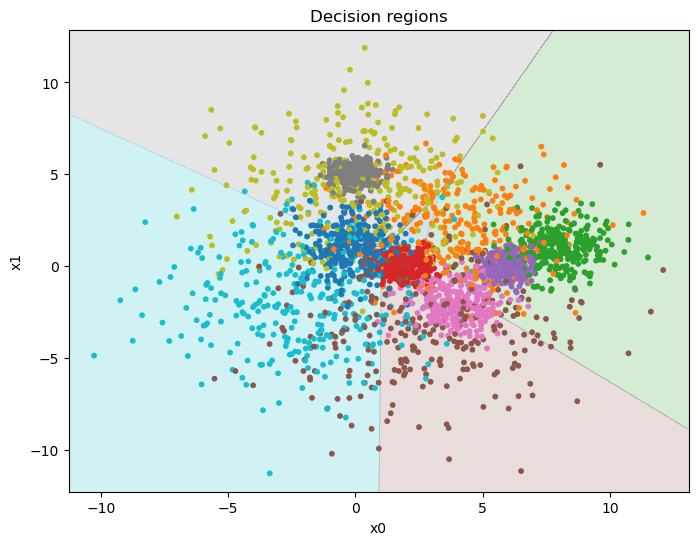

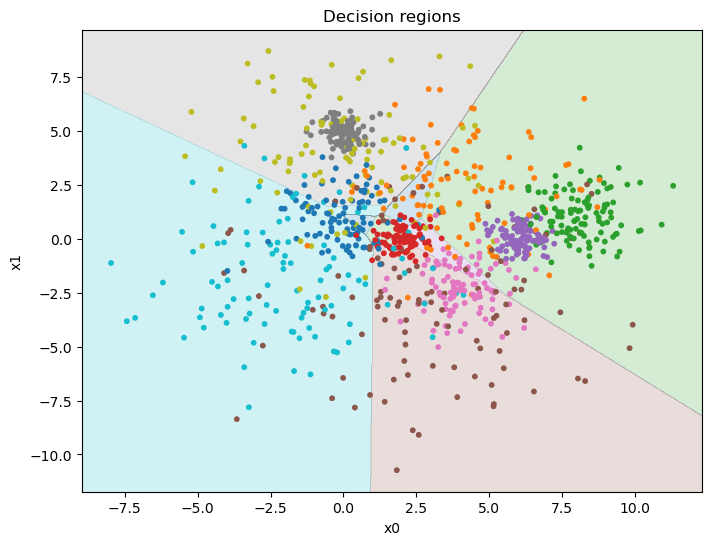

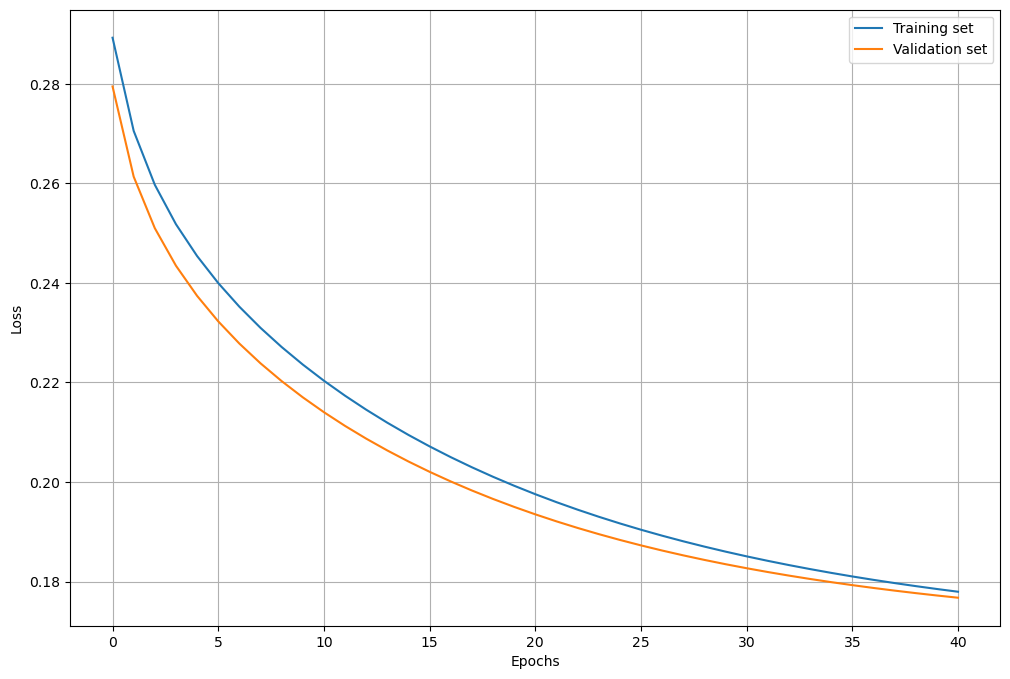

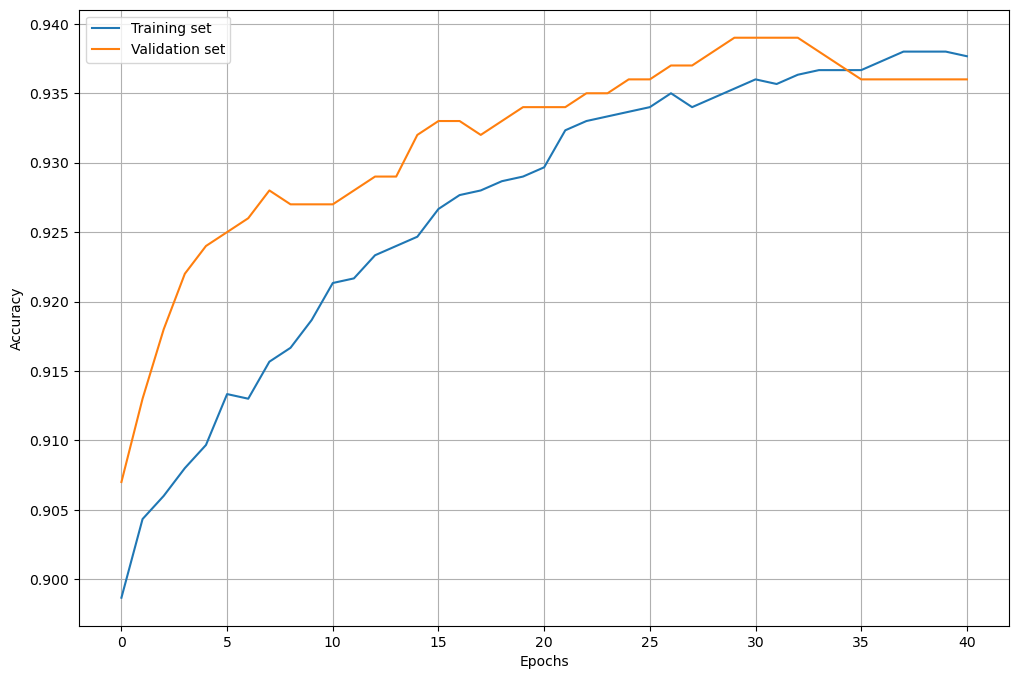

Probability (avg) for an instance belonging to class 1 in training set: 0.209 and in validation set: 0.203
Probability (avg) for an instance belonging to class 2 in training set: 0.207 and in validation set: 0.206
Probability (avg) for an instance belonging to class 3 in training set: 0.21 and in validation set: 0.213
Probability (avg) for an instance belonging to class 4 in training set: 0.214 and in validation set: 0.21
Probability (avg) for an instance belonging to class 5 in training set: 0.212 and in validation set: 0.213
Probability (avg) for an instance belonging to class 6 in training set: 0.211 and in validation set: 0.21
Probability (avg) for an instance belonging to class 7 in training set: 0.207 and in validation set: 0.206
Probability (avg) for an instance belonging to class 8 in training set: 0.211 and in validation set: 0.206
Probability (avg) for an instance belonging to class 9 in training set: 0.21 and in validation set: 0.205
Probability (avg) for an instance belongi

In [ ]:
class Multi(NumpyClassifier):
    def __init__(self, bias=-1, numEpochs=2):
        self.bias=bias
        self.numEpocks=numEpochs
    
    def forward(self, X):
        return logistic(X @ self.weights)


    def fit(self, x_t, t_t, X_val=None, t_val=None, eta=0.1, tol=0.001):
        self.models = []
        #make a binary classifier for each of the classes
        for i in range(max(t_multi_train)+1):
            logreg = NumpyLogReg()
            binary_multi_t = np.array([1 if label == i else 0 for label in t_t])
            binary_multi_v = np.array([1 if label == i else 0 for label in t_val])
            loss_t = []
            loss_v = []
            acc_t = []
            acc_v = [] 
            nEpc = 0

            #if we check both training and validation:
            if X_val is not None and t_val is not None:
                loss_t, loss_v, acc_t, acc_v, nEpc = logreg.fit(x_t, binary_multi_t, X_val=X_val, t_val=binary_multi_v, eta=eta, tol = tol)
            else:
                loss_t, loss_v, acc_t, acc_v, nEpc = logreg.fit(x_t, binary_multi_t, eta=eta, tol = tol)
            self.models.append(logreg)
        return loss_t, loss_v, acc_t, acc_v, nEpc
    
    #predicting the probability of a model to belong to a class
    def predict(self, x, threshold=0.5):
        probability = []
        for model in self.models:
            prob_class = model.predict_probabilities(x)
            probability.append(prob_class)
        probability = np.array(probability)
        return np.argmax(probability, axis=0)
    
    #when t = 1, P(t|x) = y = 1/(1+e^(-w*x)) = forward(z)
    #note: x should have already been multiplied with the weights
    def predict_probabilities(self, x):
        """X is a Kxm matrix for some K>=1
        predict the probability of the value belonging to the positive class"""
        #don't want to add bias twice. if we don't have 3 columns yet, the bias is not added
        if x.shape[1] == 2:
            z = add_bias(x, self.bias)
        else:
            z = x
        y = self.forward(z)
        return y

    #TASK 1F
    def tune_multi(self, x_t,t_t,x_v,t_v):
        bestLearningRate = 0.1
        bestTol = 0.001
        loss_t, loss_v, acc_t, acc_v, nEpc = self.fit(x_t, t_t, X_val=x_v, t_val=t_v, eta=bestLearningRate, tol=bestTol)
        bestAcc = accuracy(self.predict(x_v), t_v)
        best_loss_t = loss_t
        best_loss_v = loss_v
        best_acc_t = acc_t
        best_acc_v = acc_v
        best_epc = nEpc
        better_lr = []
        better_Tol = []

        #checking value-combinations for learning rate and epc
        learning_rates = [0.04, 0.06, 0.08, 0.2, 0.4]
        tols = [0.0006, 0.0008, 0.002, 0.004, 0.006]
        for i in range(len(learning_rates)):
            for j in range(len(tols)):
                loss_t, loss_v, acc_t, acc_v, nEpc = self.fit(x_t, t_t, X_val=x_v, t_val=t_v, eta=learning_rates[i], tol=tols[j])
                acc = accuracy(self.predict(x_v), t_v)
                if(acc > bestAcc):
                    better_lr.append(learning_rates[i])
                    better_Tol.append(tols[i])
                    bestAcc = acc
                    bestLearningRate = learning_rates[i]
                    bestTol = tols[i]
                    best_loss_t = loss_t
                    best_loss_v = loss_v
                    best_acc_t = acc_t
                    best_acc_v = acc_v
                    best_epc = nEpc
        best_performance_list = [bestAcc,bestTol,bestLearningRate, better_Tol, better_lr, best_loss_t, best_loss_v, best_acc_t, best_acc_v, best_epc]
        return best_performance_list
    
    #defining standard scaler
    def scale_multi(self, data):
        scale = [2]
        #calculates the mean of each column  axis=0 means for each column
        mean = np.mean(data, axis=0)
        #calculates the standard devation of each column
        stdDeviation = np.std(data, axis=0)
        #scaling the data
        output = np.zeros([len(data),len(data[0])])
        for i in range(len(data[0])):
            for j in range(len(data)):
                output[j][i] = (data[j][i]-mean[i])/stdDeviation[i]
        return output
    
    def print_performance(self, bestList):
        # bestList: bestAcc,bestTol,bestLearningRate, better_Tol, better_lr
        print(f"Best fit: \n\tLearning rate: {bestList[2]} \n\tTolerance: {bestList[1]}\n\tBest accuracy: {bestList[0]}\n\tNumber of epochs: {best[9]}")
        print(f"Some good values (in combination with eachother): \n\tLearning rate: {bestList[4]} \n\tTolerance: {bestList[3]}")

    # #TASK 1F
    def plot_fitness_vs_epochs(self, loss_t, loss_v):
        epc = list(range(len(loss_t)))
        plt.figure(figsize=(12,8))
        plt.plot(epc, loss_t, label=f'Training set')
        plt.plot(epc, loss_v, label=f'Validation set')
        plt.xlabel("Epochs")
        plt.ylabel("Loss")
        plt.grid(True)
        plt.legend()
        plt.show()
    
    def plot_acc_vs_epochs(self, acc_t, acc_v):
        epc = list(range(len(acc_t)))
        plt.figure(figsize=(12,8))
        plt.plot(epc, acc_t, label=f'Training set')
        plt.plot(epc, acc_v, label=f'Validation set')
        plt.xlabel("Epochs")
        plt.ylabel("Accuracy")
        plt.grid(True)
        plt.legend()
        plt.show()
    
    def predict_each_class(self, x):
        probability = []
        for model in self.models:
            prob_class = model.predict_probabilities(x)
            probability.append(prob_class)
        probability = np.array(probability)
        
        prob_for_ith_class = []
        for j in range(len(probability[0])):
            ith_class = []
            for i in range(len(probability)):
                ith_class.append(probability[i][j])
            prob_for_ith_class.append(ith_class)
        prob_for_ith_class = np.array(prob_for_ith_class)
        prob_for_ith_class = np.mean(prob_for_ith_class, axis=0)
        return prob_for_ith_class




multi = Multi()
multi.scale_multi(X_train)
best = multi.tune_multi(X_train, t_multi_train, X_val, t_multi_val)
multi.print_performance(best)
plot_decision_regions(X_train, t_multi_train, multi)
plot_decision_regions(X_val, t_multi_val, multi)
multi.plot_fitness_vs_epochs(best[5], best[6])
multi.plot_acc_vs_epochs(best[7], best[8])

multiBest = best

# Our classifier is not ideal. But is it because all the 10 classes are equally diffucult to predict?
# You should evaluate the multinomial model predictions for each class separately and report your findings.
# Please also report whether there is any difference in this respect between the training and the validation sets.
prob_train = multi.predict_each_class(X_train)
prob_val = multi.predict_each_class(X_val)
biggestDiff = 0
diffClass = -1
for i in range(len(prob_train)):
    print(f"Probability (avg) for an instance belonging to class {i+1} in training set: {np.round(prob_train[i],3)} and in validation set: {np.round(prob_val[i],3)}")
    difference = np.abs(prob_train[i]-prob_val[i])
    if difference > biggestDiff:
        biggestDiff = difference
        diffClass = i+1
print(f"The biggest difference is {np.round(biggestDiff,4)} at class {diffClass}")

#findings: all the classes have very similar probabilities




# Part 2 Multi-layer neural networks

## A first non-linear classifier

The following code is a simple implementation of a multi-layer perceptron or feed-forward neural network.
For now, it is quite restricted.
There is only one hidden layer with 6 neurons.
It can only handle binary classification.
In addition, it uses a simple final layer similar to the linear regression classifier above.
One way to look at it is what happens when we add a hidden layer to the linear regression classifier.

The MLP class below misses the implementation of the `forward()` function. Your first task is to implement it. 

Remember that in the forward pass, we "feed" the input to the model, the model processes it and produces the output. The function should make use of the logistic activation function and bias.

In [408]:
# First, we define the logistic function and its derivative:
def logistic(x):
    # print(x)
    return (1/(1+np.exp(-x)))

def logistic_diff(y):
    return y * (1 - y)

Results for best tuning og the best run (out of 3)
Best fit: 
	Learning rate: 0.0002 
	Tolerance: 2e-05
	Best accuracy: 0.85
	Number of epochs: 729 
	Size of hidden layer: 10
Some good values (in combination with eachother): 
	Learning rate: [0.0001, 0.0001, 0.0002] 
	Tolerance: [1e-05, 1e-05, 2e-05]


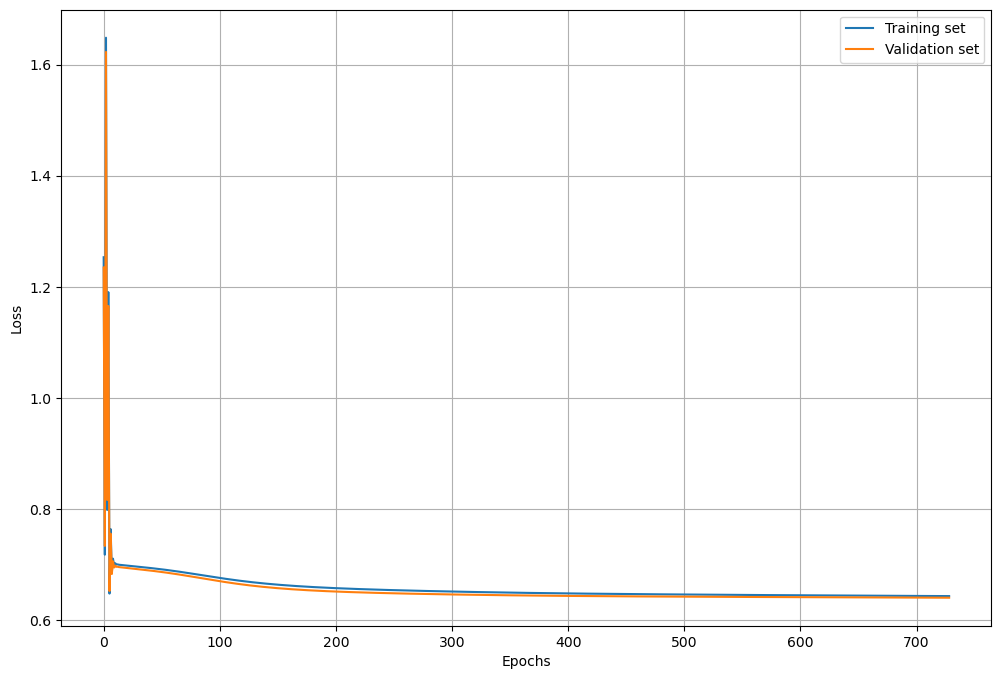

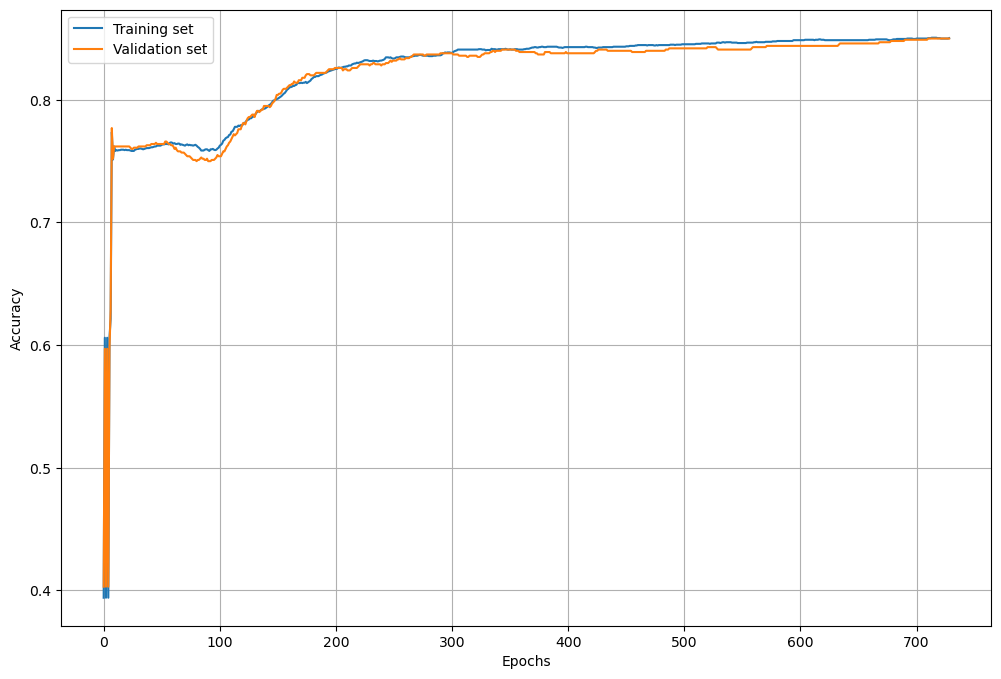

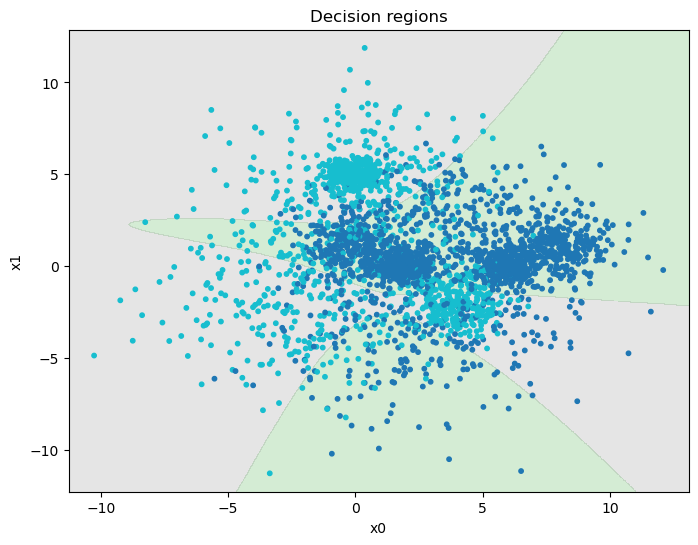

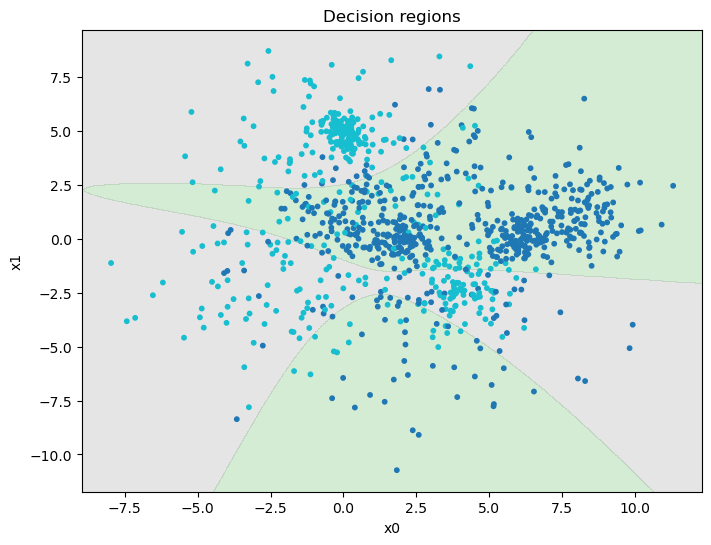

Accuracy mean of 3 runs:  0.801
Accuracy standard deviation of 3 runs:  0.004


In [ ]:
class MLPBinaryLinRegClass(NumpyClassifier):
    """A multi-layer neural network with one hidden layer"""
    
    def __init__(self, bias=-1, dim_hidden = 6):
        """Intialize the hyperparameters"""
        self.bias = bias
        # Dimensionality of the hidden layer
        self.dim_hidden = dim_hidden
        self.activ = logistic
        self.activ_diff = logistic_diff
        
    def forward(self, X):
        """TODO: 
        Perform one forward step. 
        Return a pair consisting of the outputs of the hidden_layer
        and the outputs on the final layer"""
        
        #adding weights and bias tot eh first layer and feeding to forward
        hidden = self.activ(X @ self.weights1)
        hidden = add_bias(hidden, self.bias)
        

        #adding weights to the input for the last layer (output)
        outputs = hidden @ self.weights2
        return hidden, outputs
    
    def fit(self, X_train, t_train, X_val, t_val, eta=0.00001, epochs = 100, tol = 0.00001, n_epochs_no_update = 2, dimsHidden = 1):
        """Initialize the weights. Train *epochs* many epochs.
        X_train is a NxM matrix, N data points, M features
        t_train is a vector of length N of targets values for the training data, 
        where the values are 0 or 1.
        lr is the learning rate
        """
        self.lr = eta
        losses = []
        losses_val = []
        accuracy_train = []
        accuracy_val = []
        index = 0
        n_epochs = n_epochs_no_update
        
        # Turn t_train into a column vector, a N*1 matrix:
        T_train = t_train.reshape(-1,1)
            
        dim_in = X_train.shape[1] 
        dim_out = T_train.shape[1]
        
        # Initialize the weights
        self.weights1 = (np.random.rand(dim_in + 1, self.dim_hidden) * 2 - 1)/np.sqrt(dim_in)
        self.weights2 = (np.random.rand( self.dim_hidden+1, dim_out) * 2 - 1)/np.sqrt(self.dim_hidden)
        X_train_bias = add_bias(X_train, self.bias)
        
        #TASK E)
        while(n_epochs>0):
        # for j in range(100):
            # One epoch
            # The forward step:
            hidden_outs, outputs = self.forward(X_train_bias)
            # The delta term on the output node:
            out_deltas = (outputs - T_train)
            # The delta terms at the output of the hidden layer:
            hiddenout_diffs = out_deltas @ self.weights2.T
            # The deltas at the input to the hidden layer:
            hiddenact_deltas = (hiddenout_diffs[:, 1:] *self.activ_diff(hidden_outs[:, 1:]))  
            # Update the weights:
            self.weights2 -= self.lr * hidden_outs.T @ out_deltas
            self.weights1 -= self.lr * X_train_bias.T @ hiddenact_deltas 

            #TASK B)
            pred_prob = self.predict_probabilities(X_train)
            losses.append(np.mean(-t_train*np.log(pred_prob+1e-10)-(1-t_train)*(np.log(1-pred_prob+1e-10))))
            accuracy_train.append(accuracy(self.predict(X_train), t_train))

            #TASK C)
            if X_val is not None and t_val is not None:
                pred_prob = self.predict_probabilities(X_val)
                #addiing +1e-10 so it doesent calculate log to 0 or 1
                losses_val.append(np.mean(-t_val*np.log(pred_prob+1e-10)-(1-t_val)*(np.log(1-pred_prob+1e-10))))
                accuracy_val.append(accuracy(self.predict(X_val), t_val))

            if index > 0 and (losses[index-1]-losses[index]<tol):
                n_epochs-=1
            elif index>0:
                n_epochs = n_epochs_no_update
            index += 1

        #TASK D)
        nEpc = len(losses)
        return losses, losses_val, accuracy_train, accuracy_val, nEpc

    
            
    
    def predict(self, X):
        """Predict the class for the members of X"""
        Z = add_bias(X, self.bias)
        forw = self.forward(Z)[1]
        score = forw[:, 0]
        return (score > 0.5)
    
    #TASK A) making a function for predicting probabilities
    def predict_probabilities(self, X):
        Z = add_bias(X, self.bias)
        forw = self.forward(Z)[1]
        score = forw[:, 0]
        return self.activ(score)
    

    #TASK E)
    def tune(self, x_t,t_t,x_v,t_v):
        bestLearningRate = 0.001
        bestTol = 0.0001
        bestDimHidden = self.dim_hidden
        loss_t, loss_v, acc_t, acc_v, nEpc = self.fit(X_train, t2_train, X_val, t2_val, eta=bestLearningRate, tol = bestTol, n_epochs_no_update = 2)
        bestAcc = accuracy(self.predict(x_v), t_v)
        best_loss_t = loss_t
        best_loss_v = loss_v
        best_acc_t = acc_t
        best_acc_v = acc_v
        best_epc = nEpc
        better_lr = []
        better_Tol = []

        #checking value-combinations for learning rate and epc
        learning_rates = [0.0001, 0.0002]
        tols = [0.00001, 0.00002]
        dims = [2,10]
        for i in range(len(learning_rates)):
            for j in range(len(tols)):
                for k in range(len(dims)):
                    self.dim_hidden = dims[k]
                    loss_t, loss_v, acc_t, acc_v, nEpc = self.fit(x_t, t_t, X_val=x_v, t_val=t_v, eta=learning_rates[i], tol=tols[j])
                    acc = accuracy(self.predict(x_v), t_v)
                    if(acc > bestAcc):
                        better_lr.append(learning_rates[i])
                        better_Tol.append(tols[i])
                        bestAcc = acc
                        bestLearningRate = learning_rates[i]
                        bestTol = tols[i]
                        best_loss_t = loss_t
                        best_loss_v = loss_v
                        best_acc_t = acc_t
                        best_acc_v = acc_v
                        best_epc = nEpc
                        bestDimHidden = self.dim_hidden
        best_performance_list = [bestAcc,bestTol,bestLearningRate, better_Tol, better_lr, best_loss_t, best_loss_v, best_acc_t, best_acc_v, best_epc, bestDimHidden]
        return best_performance_list
    
    #defining standard scaler
    def scale(self, data):
        scale = [2]
        #calculates the mean of each column  axis=0 means for each column
        mean = np.mean(data, axis=0)
        #calculates the standard devation of each column
        stdDeviation = np.std(data, axis=0)
        #scaling the data
        output = np.zeros([len(data),len(data[0])])
        for i in range(len(data[0])):
            for j in range(len(data)):
                output[j][i] = (data[j][i]-mean[i])/stdDeviation[i]
        return output
    
    def print_performance(self, bestList):
        # bestList: bestAcc,bestTol,bestLearningRate, better_Tol, better_lr
        print(f"Best fit: \n\tLearning rate: {bestList[2]} \n\tTolerance: {bestList[1]}\n\tBest accuracy: {bestList[0]}\n\tNumber of epochs: {best[9]} \n\tSize of hidden layer: {best[10]}")
        print(f"Some good values (in combination with eachother): \n\tLearning rate: {bestList[4]} \n\tTolerance: {bestList[3]}")

    #TASK F
    def plot_fitness_vs_epochs(self, loss_t, loss_v):
        epc = list(range(len(loss_t)))
        plt.figure(figsize=(12,8))
        plt.plot(epc, loss_t, label=f'Training set')
        plt.plot(epc, loss_v, label=f'Validation set')
        plt.xlabel("Epochs")
        plt.ylabel("Loss")
        plt.grid(True)
        plt.legend()
        plt.show()
    
    def plot_acc_vs_epochs(self, acc_t, acc_v):
        epc = list(range(len(acc_t)))
        plt.figure(figsize=(12,8))
        plt.plot(epc, acc_t, label=f'Training set')
        plt.plot(epc, acc_v, label=f'Validation set')
        plt.xlabel("Epochs")
        plt.ylabel("Accuracy")
        plt.grid(True)
        plt.legend()
        plt.show()
    


mlp = MLPBinaryLinRegClass()
mlp.scale(X_train)
best = mlp.tune(X_train, t2_train, X_val, t2_val)

print("Results for best tuning og the best run (out of 3)")
mlp.print_performance(best)
mlp.plot_fitness_vs_epochs(best[5], best[6])
mlp.plot_acc_vs_epochs(best[7], best[8])
plot_decision_regions(X_train, t2_train, mlp)
plot_decision_regions(X_val, t2_val, mlp)


#TASK G)
# bestlist bestAcc,bestTol,bestLearningRate, better_Tol, better_lr, best_loss_t, best_loss_v, best_acc_t, best_acc_v, best_epc, bestDimHidden
# losses, losses_val, accuracy_train, accuracy_val, nEpc
runs = [None]*3
for i in range(3):
    runs[i] = np.mean(mlp.fit(X_train, t2_train,X_val, t2_val, eta=best[2], tol = best[1], dimsHidden=best[10])[2])

#mean
print("Accuracy mean of 3 runs: ", np.round(np.mean(runs),3))
#std
print("Accuracy standard deviation of 3 runs: ", np.round(np.std(runs),3))

mlpBest = best




When implemented, this model can be used to make a non-linear classifier for the set `(X, t2)`. Experiment with settings for learning rate and epochs and see how good results you can get. 
Report results for various settings. Be prepared to train for a long time (but you can control it via the number of epochs and hidden size). 

Plot the training set together with the decision regions as in Part I.

# Improving the MLP classifier
You should now make changes to the classifier similarly to what you did with the logistic regression classifier in part 1.

a) In addition to the `predict()` method, which predicts a class for the data, include the `predict_probabilities()` method which predict the probability of the data belonging to the positive class. The training should be based on these values, as with logistic regression.

b) Calculate the loss and the accuracy after each epoch and store them for inspection after training.

c) Extend the `fit()` method with optional arguments for a validation set `(X_val, t_val)`. If a validation set is included in the call to `fit()`, calculate the loss and the accuracy for the validation set after each epoch.

d) Extend the `fit()` method with two keyword arguments, `tol` (tolerance) and `n_epochs_no_update` and stop training when the loss has not improved for more than `tol` after `n_epochs_no_update`. A possible default value for `n_epochs_no_update` is 2. Add an attribute to the classifier which tells us after fitting how many epochs it was trained on.

e) Tune the hyper-parameters: `lr`, `tol` and `dim-hidden` (size of the hidden layer).
Also, consider the effect of scaling the data.

f) After a succesful training with the best setting for the hyper-parameters, plot both training loss and validation loss as functions of the number of epochs in one figure, and both training and validation accuracies as functions of the number of epochs in another figure. Comment on what you see.

g) The MLP algorithm contains an element of non-determinism. Hence, train the classifier 3 times with the optimal hyper-parameters and report the mean and standard deviation of the accuracies over the 3 runs.

## For IN4050-students: Multi-class neural network

The following part is only mandatory for IN4050 students. IN3050 students are also welcome to make it a try. This is the most fun part of the set :) )

The goal is to use a feed-forward neural network for non-linear multi-class classfication and apply it to the set `(X, t_multi)`.

Modify the network to become a multi-class multinomial classifier. As a sanity check of your implementation, you may apply it to `(X, t_2)` and see whether you get similar results as above.

Train the resulting classifier on `(X_train, t_multi_train)`, test it on `(X_val, t_multi_val)`, tune the hyper-parameters and report the accuracy.

Plot the decision boundaries for your best classifier. Evaluate the  best model predictions for each class separately (same as in part 1)  and report your findings. Please also report whether there is any difference in this respect between the training and the validation sets.

# Part III: Final testing
We can now perform a final testing on the held-out test set we created in the beginning.

## Binary task (X, t2)
Consider the linear regression classifier, the logistic regression classifier and the multi-layer network with the best settings you found. Train each of them on the training set and evaluate on the held-out test set, but also on the validation set and the training set. Report the performance in a 3 by 3 table.

Comment on what you see. How do the three different algorithms compare? Also, compare the results between the different dataset splits. In cases like these, one might expect slightly inferior results on the held-out test data compared to the validation and training data. Is this the case? 

Also report precision and recall for class 1.

In [466]:

#linear regression
#bestlist: [bestAcc, bestEpc, bestLearningRate, better_epc, better_lr]
linearReg = NumpyLinRegClass()
linearReg.fit(X_train, t2_train, lr = linRegBest[2], epochs=linRegBest[1])
accLinReg = [0]*3
accLinReg[0] = accuracy(linearReg.predict(X_test), t2_test)
accLinReg[1] = accuracy(linearReg.predict(X_val), t2_val)
accLinReg[2] = accuracy(linearReg.predict(X_train), t2_train)

#logistic regression
#best list: bestAcc,bestTol,bestLearningRate, better_Tol, better_lr, best_loss_t, best_loss_v, best_acc_t, best_loss_v,best_epc
logReg = NumpyLogReg()
logReg.fit(X_train, t2_train, eta = logRegBest[2], X_val = X_val, t_val = t2_val, tol=logRegBest[1])
acclogReg = [0]*3
acclogReg[0] = accuracy(logReg.predict(X_test), t2_test)
acclogReg[1] = accuracy(logReg.predict(X_val), t2_val)
acclogReg[2] = accuracy(logReg.predict(X_train), t2_train)

#Multi layer classifier (using the one from previous task to not wait for long runtimes)
#best list: bestAcc,bestTol,bestLearningRate, better_Tol, better_lr, best_loss_t, best_loss_v, best_acc_t, best_acc_v, best_epc, bestDimHidden
accMlp = [0]*3
accMlp[0] = accuracy(mlp.predict(X_test), t2_test)
accMlp[1] = accuracy(mlp.predict(X_val), t2_val)
accMlp[2] = accuracy(mlp.predict(X_train), t2_train)

#precition for class 1 (index 0) in multi classifier
#bestAcc,bestTol,bestLearningRate, better_Tol, better_lr, best_loss_t, best_loss_v, best_acc_t, best_acc_v, best_epc
multi = Multi()
multi.fit(X_train, t_multi_train, X_val, t_multi_val, eta= multiBest[2], tol = multiBest[1])
binary_multi_t = np.array([1 if label == 0 else 0 for label in t_multi_train])
binary_multi_v = np.array([1 if label == 0 else 0 for label in t_multi_val])
binary_multi_test = np.array([1 if label == 0 else 0 for label in t_multi_test])
accMulti = [0]*3
accMulti[0] = accuracy(multi.predict(X_test), binary_multi_test)
accMulti[1] = accuracy(multi.predict(X_val), binary_multi_v)
accMulti[2] = accuracy(multi.predict(X_train), binary_multi_t)


print(f"Accuracy for: \t\t\t|\tTest set: \t|\t Val set: \t|\t Train set:")
print("--------------------------------------------------------------------------------------")
print(f"Linear Regression\t\t|\t{accLinReg[0]}\t|\t {accLinReg[1]}\t|\t{accLinReg[2]}")
print(f"Logistic Regression\t|\t{acclogReg[0]}\t|\t {acclogReg[1]}\t|\t{np.round(acclogReg[2],3)}")
print(f"Multi Layer\t\t\t|\t{accMlp[0]}\t|\t{accMlp[1]}\t\t|\t{np.round(accMlp[2],3)}")
print(f"Multi class\t\t\t|\t{accMulti[0]}\t|\t{accMulti[1]}\t|\t{np.round(accMulti[2],3)}")
#the accuracy didn't match with the accuracies from previous tasks, i don't know why. espessially with Mlp becaus ei used the same trained model





Accuracy for: 			|	Test set: 	|	 Val set: 	|	 Train set:
--------------------------------------------------------------------------------------
Linear Regression		|	0.767	|	 0.774	|	0.776
Logistic Regression	|	0.765	|	 0.773	|	0.763
Multi Layer			|	0.687	|	0.68		|	0.697
Multi class			|	0.004	|	0.002	|	0.004


## For IN4050-students: Multi-class task (X, t_multi)

The following part is only mandatory for IN4050-students. IN3050-students are also welcome to give it a try though.

Compare the three multi-class classifiers: the standard multi-class and the multinomial logistic regression from part one and the multi-class neural network from part two. Evaluate on test, validation and training set as above.

Comment on the results.